# Modelling E.coli infections during a flood event in Beira, Mozambique

## Setup

### Import dependencies

In [11]:
# Install packages
required_packages = ["numpy", "matplotlib", "rasterio", "tifffile", "pyyaml", "utm", "gdal"]

# Install missing packages
import sys
import subprocess

# Function to install a package if not already installed
def install_if_missing(pkg_name, import_name=None):
    try:
        if import_name:
            __import__(import_name)
        else:
            __import__(pkg_name)
    except ImportError:
        print(f"Installing {pkg_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])

# Install all required packages
for pkg in required_packages:
    # Handle special case: pyyaml is installed as 'pyyaml' but imported as 'yaml'
    import_name = "yaml" if pkg == "pyyaml" else pkg
    install_if_missing(pkg, import_name)

print("All required packages are installed!")

Installing gdal...
All required packages are installed!


In [13]:
# Import dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject, Resampling
import tifffile as tf
import yaml
import utm
from osgeo import gdal

### Define pathogen

In [17]:
pathogen = 'E.coli' # select the pathogen for the simulation. Only option at the moment is 'E.coli'

### Define functions

In [15]:
def load_tiff(file_path, dtype=np.float32):
    """Loads a TIFF file and handles NoData values."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with tf.TiffFile(file_path) as tif:
        data = tif.asarray().astype(dtype)
        no_data_value = tif.pages[0].tags.get('GDAL_NODATA', None)

        if no_data_value:
            try:
                no_data_value = float(no_data_value.value)
                data[data == no_data_value] = np.nan  # Set NoData to NaN
            except ValueError:
                pass  # Ignore if conversion fails

    return data

def load_multiband_tiff(file_path):
    """Loads a multi-band TIFF file (e.g., population density)."""
    dataset = gdal.Open(file_path)
    if dataset is None:
        raise RuntimeError(f"Failed to open dataset: {file_path}")

    bands = dataset.RasterCount  # Get number of bands
    return np.array([dataset.GetRasterBand(i + 1).ReadAsArray().astype(np.float32) for i in range(bands)])

def get_utm_zone(source_path):
    """Get most appropriate UTM zone for area in question"""
    with rasterio.open(source_path) as src:
        bounds = src.bounds
    
    # Calculate the center latitude and longitude of the raster
    center_lon = (bounds.left + bounds.right) / 2
    center_lat = (bounds.top + bounds.bottom) / 2
    
    # Get UTM zone information from lat/lon
    utm_zone = utm.from_latlon(center_lat, center_lon)
    
    # Extract zone number and hemisphere
    zone_number = utm_zone[2]
    hemisphere = utm_zone[3]
    
    # If the latitude is negative, it's in the southern hemisphere
    if center_lat < 0:
        hemisphere = 'S'
    
    # Determine the EPSG code based on hemisphere and zone number
    if hemisphere == 'S':
        epsg_code = 32700 + zone_number  # Southern Hemisphere
    else:
        epsg_code = 32600 + zone_number  # Northern Hemisphere

    return epsg_code

def get_cell_area(source_path):
    """"Get area of gridcell in m2."""
    with rasterio.open(source_path) as src:
        # Transform the raster to a CRS with units in meters
        dst_crs = get_utm_zone(source_path)
        transform, width, height = rasterio.warp.calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)

        # Create an empty array to store reprojected data (not saving to disk)
        reprojected_data = np.empty((height, width), dtype=src.dtypes[0])
        
        # Reproject the raster data into the new CRS
        reproject(
            source=rasterio.band(src, 1),
            destination=reprojected_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
        )
        
        # Cell dimensions in meters
        cell_width = transform[0]  # X resolution
        cell_height = -transform[4]  # Y resolution (negative because Y decreases in raster)
        
        # Area of a single cell
        cell_area = cell_width * cell_height
        return cell_area

       
        # Create an empty array to store reprojected data (not saving to disk)
        reprojected_data = np.empty((height, width), dtype=src.dtypes[0])
        
        # Reproject the raster data into the new CRS without saving to a file
        reproject(
            source=rasterio.band(src, 1),
            destination=reprojected_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
        )
        
        # Cell dimensions in meters (after reprojection)
        cell_width = transform[0]  # X resolution
        cell_height = -transform[4]  # Y resolution (negative because Y decreases in raster)
        
        # Area of a single cell
        cell_area = cell_width * cell_height
        return cell_area

def plot_raster(data, cmap, title, save_path=None, vmin=None, vmax=None):
    """Plots raster data with a colorbar."""
    fig, ax = plt.subplots(figsize=(10, 6))
    norm = Normalize(vmin=vmin or np.nanmin(data), vmax=vmax or np.nanmax(data))
    im = ax.imshow(data, cmap=cmap, norm=norm)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(title)
    ax.set_title(title)

    if save_path:
        plt.savefig(save_path)
    plt.show()

def calculate_infection_risk(dose, N50, alpha):
    """Calculates infection risk using beta-poisson model."""
    return 1 - (1 + (dose / N50) * (2 ** (1 / alpha) - 1)) ** -alpha

### Set file names and load data
- Flood file: Tiff file showing flood depth (in metres, there are some positive values in this file which should be negative - the code below deals with this)
- Demographic file: Tiff file with three bands showing: Number of children, number of adults, population density
- Emissions file: Tiff file with four bands showing: Population density (same as in demographic file), urban/rural classification (i.e. which gridcells are which), E.Coli emissions per gridcell (CFU/100mL), emissions reduction factor (based on sanitation factors).

The code to generate the emissions file is in Pre_processing_GDP_sanitation.py

In [33]:
flood_file = 'flooded_zoom_new.tif'
demographic_file ='clipped_population.tif'
emissions_file = 'ecoli_emissions_cropped.tif'

output_location = 'outputs'

# Load single-band flood data
flood = load_tiff(flood_file)
# If there are positive values, make these negative
flood[flood>0] = -flood[flood>0]

# Load multi-band population data (Children, Adults, Population Density)
children, adults, popdens = load_multiband_tiff(demographic_file)

# Load multiband emissions data
popdens2, urbanRural, emissions, reductionFactor = load_multiband_tiff(emissions_file)

## Calculate E.coli concentration
Concentration of E.coli/m3 = E.coli emissions per gridcell / floodwater volume per gridcell (m3)

Floodwater volume per gridcell (m3) = area of gridcell (m2) * flood depth (m)

In [28]:
# get area of gridcell in m2
cell_area = get_cell_area(flood_file)

# Calculate E.coli concentration/100ml
# In denominator: Multiply by -1 because flood depths are negative
# In denominator: Multiply by 10000 to convert to concentrations per 100ml
EcoliConc = emissions/(cell_area * (-1) * flood*10000)

## Plot maps ###

Plot maps of: Flooded area, population density in flooded area, E.coli emissions, E.coli concentration
Save maps to output directory

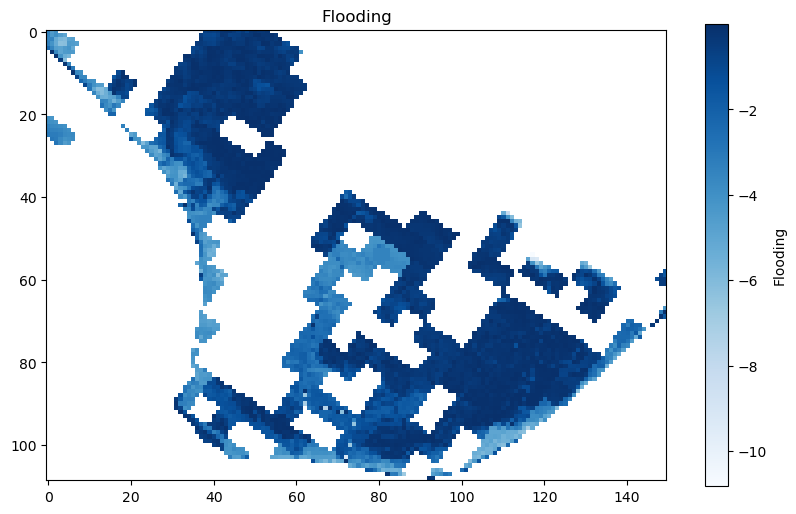

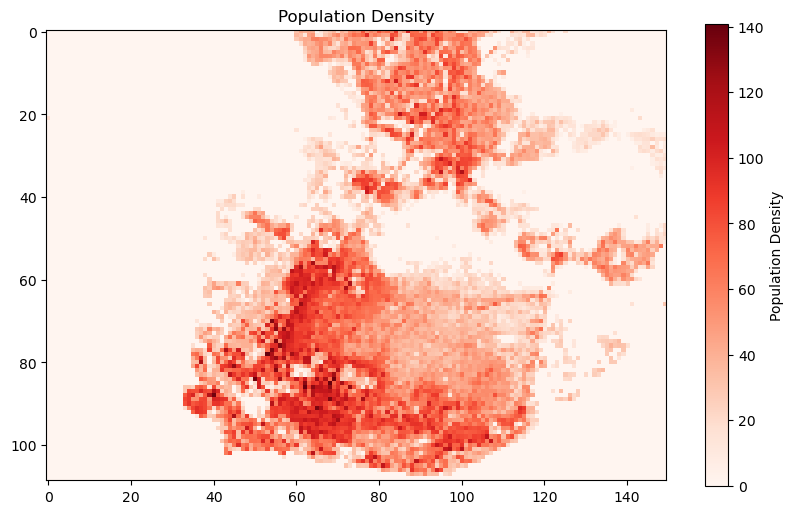

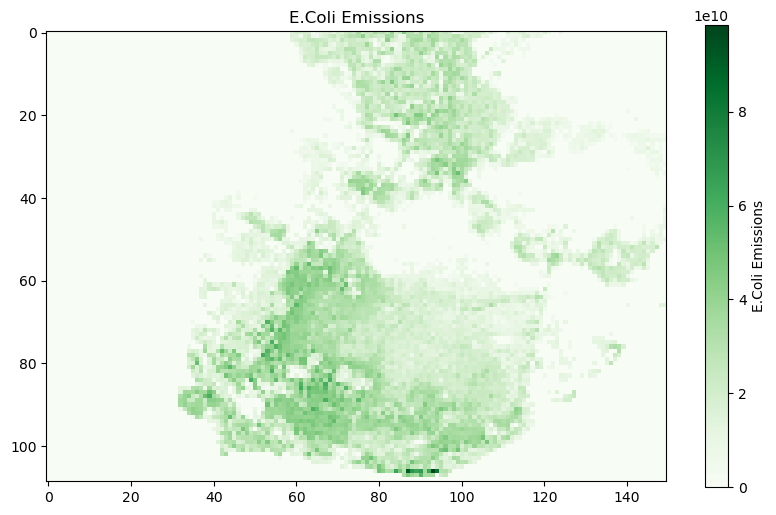

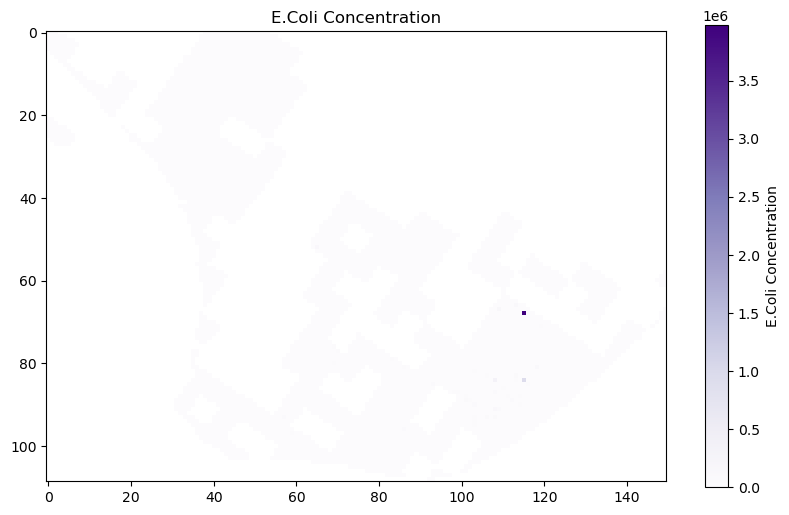

In [35]:
plot_raster(flood, cmap='Blues', title="Flooding", save_path=os.path.join(output_location, 'Flooding_Map.png'))
plot_raster(popdens, cmap='Reds', title="Population Density", save_path=os.path.join(output_location, 'Population_Density_Map.png'))
plot_raster(emissions, cmap='Greens', title="E.Coli Emissions", save_path=os.path.join(output_location, 'Ecoli_Emissions_Map.png'))
plot_raster(EcoliConc, cmap='Purples', title="E.Coli Concentration", save_path=os.path.join(output_location, 'Ecoli_Concentration_Map.png'))

## Visualize & calculate affected population
In the part below, some overlays are made to link flooding to population density to get info how many people are affected by the flood & how they are affected. The latter has been expressed by linking water depth to 'behavior' like wading and swimming.

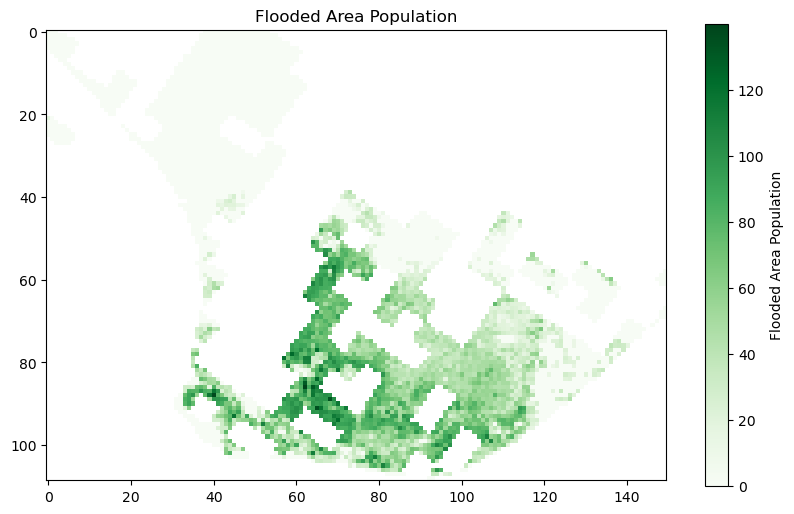

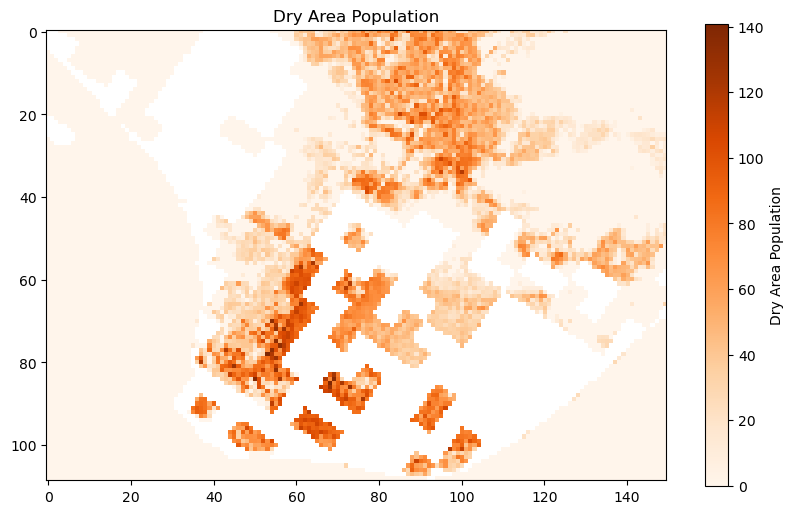

In [38]:
### create overlays to get the population density in the dry and flooded areas ###
overl_flarea = np.where(flood >= np.nanmin(flood),popdens,np.nan) 
overl_dryarea = np.where(np.isnan(flood),popdens,np.nan)

### plot the overlays ###
plot_raster(overl_flarea, cmap='Greens', title="Flooded Area Population", save_path=os.path.join(output_location, 'Flooded_Area_Population.png'))
plot_raster(overl_dryarea, cmap='Oranges', title="Dry Area Population", save_path=os.path.join(output_location, 'Dry_Area_Population.png'))

In [40]:
### Give info on the population in the flooded and dry areas ###
print('total inhabitants in total area:', round(np.nansum(popdens),0))
print('total inhabitants in flooded area:', round(np.nansum(overl_flarea),0), '(', round((np.nansum(overl_flarea)/np.nansum(popdens))*100,0),'%)')
print('total inhabitants in dry area:', round(np.nansum(overl_dryarea),0), '(', round((np.nansum(overl_dryarea)/np.nansum(popdens))*100,0),'%)')
children_flooded = np.where(flood >= np.nanmin(flood),children,np.nan)
adults_flooded = np.where(flood >= np.nanmin(flood),adults,np.nan) 
print('total children in flooded area:', round(np.nansum (children_flooded),0), '(', round((np.nansum(children_flooded)/np.nansum(children))*100,0),'%)')
print('total adults in flooded area:', round(np.nansum (adults_flooded),0), '(', round((np.nansum(adults_flooded)/np.nansum(adults))*100,0),'%)')


total inhabitants in total area: 315801.0
total inhabitants in flooded area: 125699.0 ( 40.0 %)
total inhabitants in dry area: 190102.0 ( 60.0 %)
total children in flooded area: 28463.0 ( 40.0 %)
total adults in flooded area: 97236.0 ( 40.0 %)


## Create classes for the flooded area

Four flooding water depths are assumed:
* 0-0.1m (value 1): no additional exposure over not flooded
* 0.1-0.5m (value 2): children and adults wading
* 0.5-1.5m (value 3): children swimming, adults wading
* \>1.5m (value 4): children and adults swim

In [43]:
### Create claases for the flooded area ###

wclass = flood.copy()                                    # create a copy of the flood map
wclass[wclass>0]=np.nan                                  # filter the dry land out        
wclass[np.logical_and(wclass<0,wclass>=-0.1)]= 1         # assign the classes
wclass[np.logical_and(wclass<-0.1,wclass>=-0.5)]=2                                  
wclass[np.logical_and(wclass<-0.5,wclass>=-1.5)]=3
wclass[wclass<-1.5]= 4


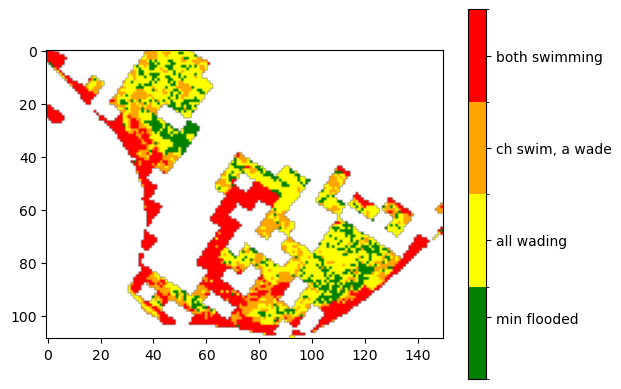

In [45]:
### Plot the classes ###

cmap = ListedColormap(['green', 'yellow', 'orange', 'red'])
bounds = [0, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots()

im = ax.imshow(wclass, cmap=cmap, norm=norm)
cbar = fig.colorbar(im, ticks=[1,2, 3,4], boundaries=bounds)
cbar.ax.set_yticklabels(['min flooded', 'all wading', 'ch swim, a wade', 'both swimming'])
plt.show()

In [47]:
### Give info on the population in the flooded area ###

# make distinction between adults & children

ch_pop_class1 = round(np.nansum(children[wclass==1]),0) 
ch_pop_class2 = round(np.nansum(children[wclass==2]),0)
ch_pop_class3 = round(np.nansum(children[wclass==3]),0)
ch_pop_class4 = round(np.nansum(children[wclass==4]),0)

print('total children in flooded area:', round(np.nansum(children_flooded),0))
print('total children in minimum flooded area:', ch_pop_class1)
print('total children in area where everyone is wading:', ch_pop_class2)
print('total children in area where children swim and adults wade:', ch_pop_class3)
print('total children in area where everyone is swimming:', ch_pop_class4)

ad_pop_class1 = round(np.nansum(adults[wclass==1]),0)
ad_pop_class2 = round(np.nansum(adults[wclass==2]),0)
ad_pop_class3 = round(np.nansum(adults[wclass==3]),0)
ad_pop_class4 = round(np.nansum(adults[wclass==4]),0)

print()
print('total adults in flooded area:', round(np.nansum(adults_flooded),0))    
print('total adults in minimum flooded area:', ad_pop_class1)
print('total adults in area where everyone is wading:', ad_pop_class2)
print('total adults in area where children swim and adults wade:', ad_pop_class3)
print('total adults in area where everyone is swimming:', ad_pop_class4)

# together with population data you know how many in each class, which can be highlighted in maps
print()
print('total inhabitants in minimum flooded area:', round(np.nansum(popdens[wclass==1]),0),'(',round((np.nansum(popdens[wclass==1])/np.nansum(popdens))*100,0),'%)')
print('total inhabitants in area where everyone is wading:', round(np.nansum(popdens[wclass==2]),0),'(',round((np.nansum(popdens[wclass==2])/np.nansum(popdens))*100,0),'%)')
print('total inhabitants in area where children swim and adults wade:', round(np.nansum(popdens[wclass==3]),0),'(',round((np.nansum(popdens[wclass==3])/np.nansum(popdens))*100,0),'%)')
print('total inhabitants in area where everyone is swimming:', round(np.nansum(popdens[wclass==4]),0),'(',round((np.nansum(popdens[wclass==4])/np.nansum(popdens))*100,0),'%)')


total children in flooded area: 28463.0
total children in minimum flooded area: 2634.0
total children in area where everyone is wading: 7590.0
total children in area where children swim and adults wade: 6395.0
total children in area where everyone is swimming: 11843.0

total adults in flooded area: 97236.0
total adults in minimum flooded area: 8999.0
total adults in area where everyone is wading: 25931.0
total adults in area where children swim and adults wade: 21848.0
total adults in area where everyone is swimming: 40458.0

total inhabitants in minimum flooded area: 11634.0 ( 4.0 %)
total inhabitants in area where everyone is wading: 33521.0 ( 11.0 %)
total inhabitants in area where children swim and adults wade: 28243.0 ( 9.0 %)
total inhabitants in area where everyone is swimming: 52301.0 ( 17.0 %)


## Read in ingestion data with YAML file
This shows how much water is ingested by children and adults when wading or swimming (values taken from literature).
Some values are per hour and some are per event. We assume that 1 event lasts 1 hour.

In [52]:
# Read exposure data from YAML file
with open("Ingestion_scenarios.yml", "r") as file:
    exposure_data = yaml.safe_load(file)

# Process exposure data
exposure_data2 = {}
event_in_hours = 1 #e.g. 1 if event lasts 1 hour; 0.25 if event lasts 15 mins
for scenario, details in exposure_data.items():
    quantity, unit = details["ing"], details["unit"]
    if unit == "ml/event":
        unit = "ml/h"
        quantity = quantity / event_in_hours
    exposure_data2[scenario] = {"ing": quantity, "unit": unit}

print(exposure_data2)

{'Wading_Adult': {'ing': 10.0, 'unit': 'ml/h'}, 'Swimming_Adult': {'ing': 30, 'unit': 'ml/h'}, 'Wading_Children': {'ing': 30.0, 'unit': 'ml/h'}, 'Swimming_Children': {'ing': 50, 'unit': 'ml/h'}}


## Calculate dose based on pathogen concentration and amount of water ingested

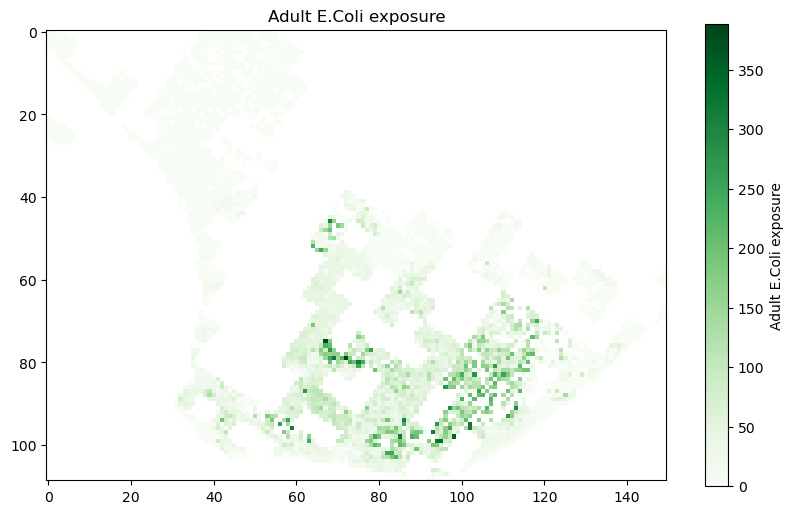

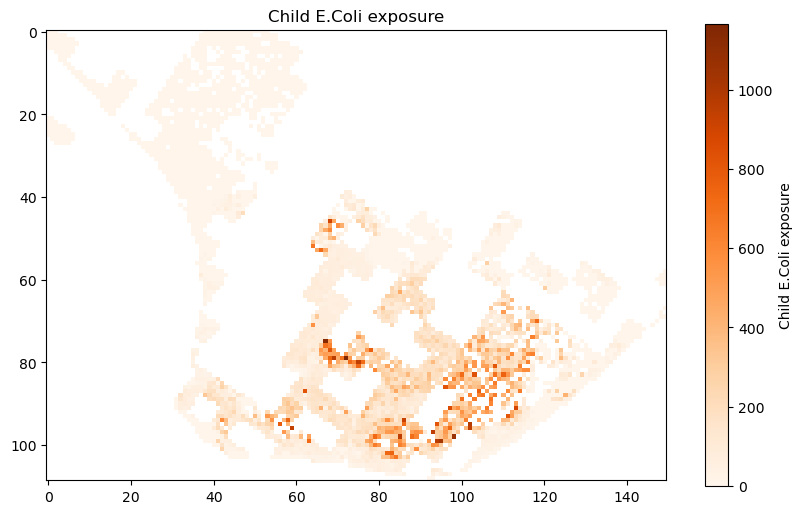

In [56]:
# display ingested E.Coli for children and adults on map

#Calculate adult dose
dose_ad = wclass.copy()
dose_ad[dose_ad==1]=np.nan
dose_ad[np.logical_or(dose_ad==2,dose_ad==3)] = exposure_data2["Wading_Adult"]["ing"]*EcoliConc[np.logical_or(dose_ad==2,dose_ad==3)]/100 #Divide by 100 because E.Coli is per 100ml
dose_ad[dose_ad==4] = exposure_data2["Swimming_Adult"]["ing"]*EcoliConc[dose_ad==4]/100

# Calculate child dose
dose_ch = wclass.copy()
dose_ch[dose_ch==1]=np.nan
dose_ch[dose_ch==2] = exposure_data2["Wading_Children"]["ing"]*EcoliConc[dose_ch==2]/100
dose_ch[np.logical_or(dose_ch==3,dose_ch==4)] = exposure_data2["Swimming_Children"]["ing"]*EcoliConc[np.logical_or(dose_ch==3,dose_ch==4)]/100

plot_raster(dose_ad, cmap='Greens', title="Adult E.Coli exposure", save_path=os.path.join(output_location, 'Adult_Ecoli_exposure.png'))
plot_raster(dose_ch, cmap='Oranges', title="Child E.Coli exposure", save_path=os.path.join(output_location, 'Child_Ecoli_exposure.png'))

## Get pathogen parameters from YAML
This provides details of how to model E.coli infection risk, based on ingested dose (values taken from literature).

We use a beta-poisson model. The beta-Poisson model is a widely used dose-response model in microbial risk assessment. It estimates the probability of infection 𝑃(𝑑) given a dose 𝑑 of a pathogen, accounting for variability in individual susceptibility. It combines two ideas:
- Poisson distribution – the number of pathogens a person is exposed to is random.
- Beta distribution – people vary in how susceptible they are to infection.

The model shows that even low doses can sometimes cause infection, and higher doses increase the risk in a smooth, realistic way. It is commonly applied to pathogens such as E. coli, norovirus, and Salmonella in food and water exposure assessments.

In [63]:
# Get pathogen parameters
with open("Pathogen_parameters.yml", "r") as file:
    pathogen_parameters = yaml.safe_load(file)

# Retrieve pathogen-specific parameters
distribution = pathogen_parameters[pathogen]["distribution"]
alpha = pathogen_parameters[pathogen]["alpha"]
beta = pathogen_parameters[pathogen]["beta"]
source = pathogen_parameters[pathogen]["source"]

print(pathogen)
print(f'Use {distribution} distribution, with alpha = {alpha} and beta = {beta} (from {source}).')

E.coli
Use beta-poisson distribution, with alpha = 0.373 and beta = 39.71 (from Teunis et al., 2008).


## Calculate and map infection Risk
Infection risk = 1 - (1 + (dose/beta))^-alpha

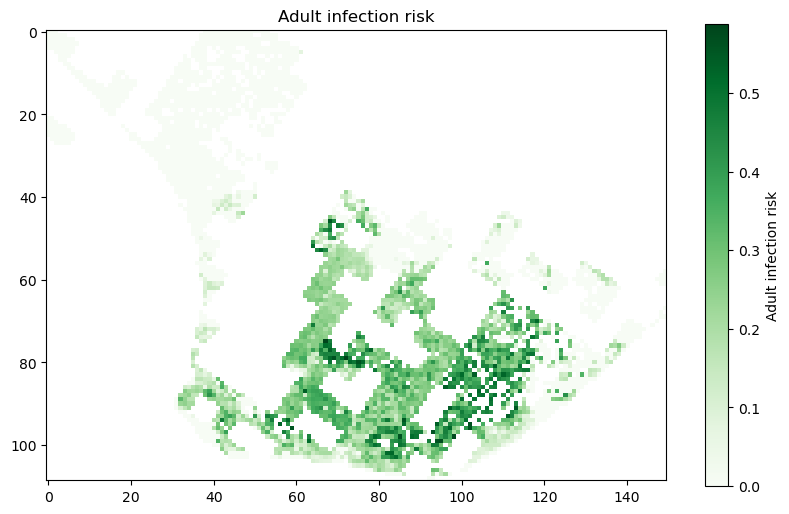

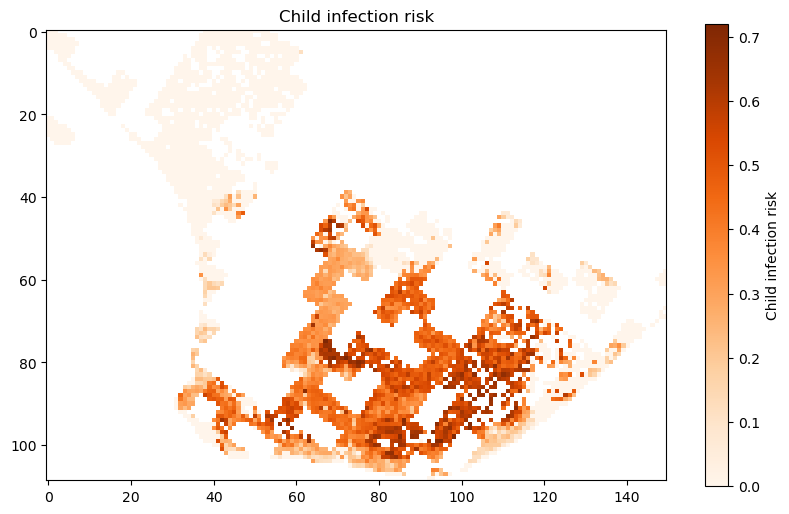

In [66]:
if distribution == "beta-poisson":
    InfRisk_Ad = 1 - (1+(dose_ad/beta))**-alpha
    InfRisk_Ch = 1 - (1+(dose_ch/beta))**-alpha

plot_raster(InfRisk_Ad, cmap='Greens', title="Adult infection risk", save_path=os.path.join(output_location, 'Adult_infection_risk.png'))
plot_raster(InfRisk_Ch, cmap='Oranges', title="Child infection risk", save_path=os.path.join(output_location, 'Child_infection_risk.png'))

## Calculate expected infected population
Expected infected population = Infection risk * Number of people

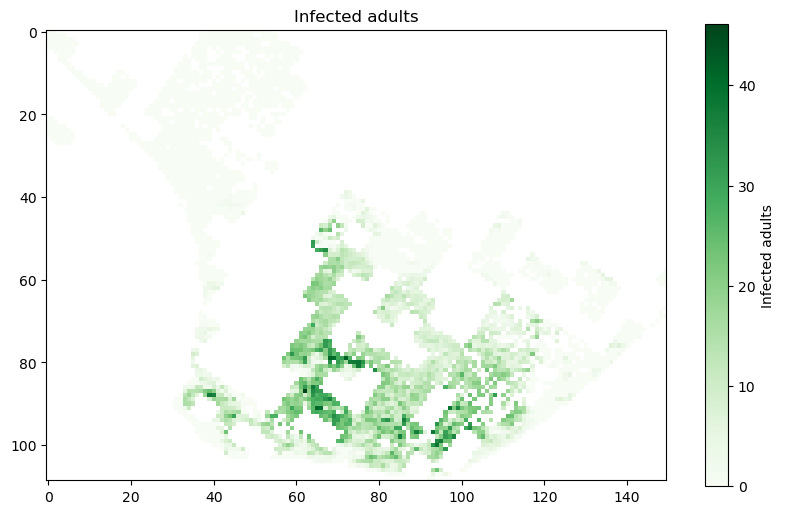

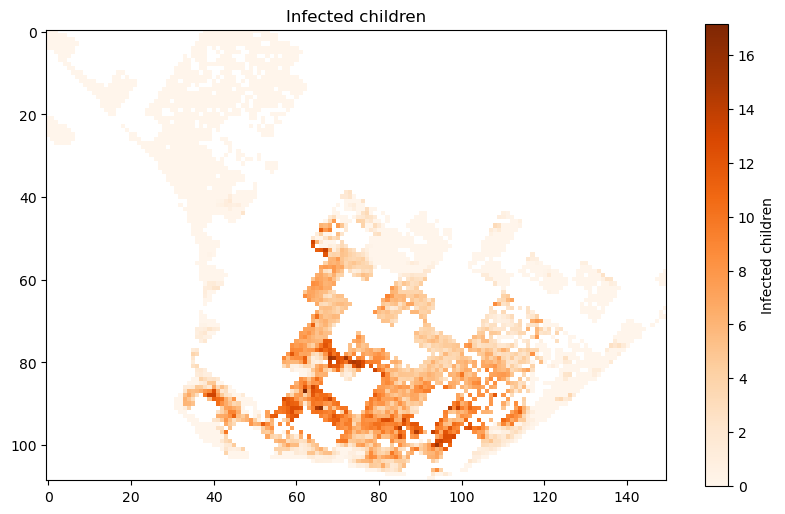

total expected infected adults: 23527
total expected infected children: 10528


In [69]:
Inf_ad = InfRisk_Ad * adults
Inf_ch = InfRisk_Ch * children

plot_raster(Inf_ad, cmap='Greens', title="Infected adults", save_path=os.path.join(output_location, 'Infected_adults.png'))
plot_raster(Inf_ch, cmap='Oranges', title="Infected children", save_path=os.path.join(output_location, 'Infected_children.png'))

print('total expected infected adults:', int(round(np.nansum(Inf_ad),0)))
print('total expected infected children:', int(round(np.nansum(Inf_ch),0)))

## Histogram Risk classes ###
Make a histogram showing how many adults and children are in each risk class.

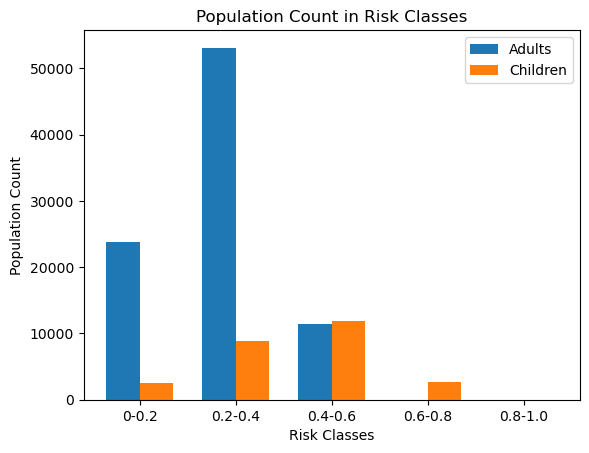

In [73]:
# Replace NaN values with 0
adults_population = np.nan_to_num(adults, nan=0)
children_population = np.nan_to_num(children, nan=0)

# Calculate the number of adults and children in each risk class
risk_classes = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
adults_count = np.zeros(len(risk_classes) - 1, dtype=float)
children_count = np.zeros(len(risk_classes) - 1, dtype=float)

for i in range(len(risk_classes) - 1):
    adults_mask = (InfRisk_Ad >= risk_classes[i]) & (InfRisk_Ad < risk_classes[i + 1])
    children_mask = (InfRisk_Ch >= risk_classes[i]) & (InfRisk_Ch < risk_classes[i + 1])

    adults_count[i] = np.sum(adults_mask * adults_population)
    children_count[i] = np.sum(children_mask * children_population)

# Plot histogram
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(len(risk_classes) - 1)

ax.bar(index, adults_count, bar_width, label='Adults')
ax.bar(index + bar_width, children_count, bar_width, label='Children')

ax.set_xlabel('Risk Classes')
ax.set_ylabel('Population Count')
ax.set_title('Population Count in Risk Classes')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels([f'{risk_classes[i]}-{risk_classes[i + 1]}' for i in range(len(risk_classes) - 1)])
ax.legend()

plt.savefig(os.path.join(output_location,'population_count_in_risk_classes.png'))
plt.show()